## Summative Part one: CO2 Emission Controller

<p style="font-size: 22px; font-weight: bold;">Understand the data</p>

Let's download and use a fuel consumption dataset, **`FuelConsumption.csv`**, which contains model-specific fuel consumption ratings and estimated carbon dioxide emissions for new light-duty vehicles for retail sale in Canada. [Dataset source](http://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64)

Here are the dataset features:
- **MODEL YEAR** e.g. 2014
- **MAKE** e.g. VOLVO
- **MODEL** e.g. S60 AWD
- **VEHICLE CLASS** e.g. COMPACT
- **ENGINE SIZE** e.g. 3.0
- **CYLINDERS** e.g 6
- **TRANSMISSION** e.g. AS6
- **FUEL TYPE** e.g. Z
- **FUEL CONSUMPTION in CITY(L/100 km)** e.g. 13.2
- **FUEL CONSUMPTION in HWY (L/100 km)** e.g. 9.5
- **FUEL CONSUMPTION COMBINED (L/100 km)** e.g. 11.5
- **FUEL CONSUMPTION COMBINED MPG (MPG)** e.g. 25
- **CO2 EMISSIONS (g/km)** e.g. 182 

My task will be to create a multiple linear regression model using some of these features to predict CO2 emissions of unobserved cars based on the selected features. 


<p style="font-size: 22px; font-weight: bold;">Data source</p>
The dataset we will use resides at the following URL:

In [4]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"

<p><strong style="font-size:20px;">Let's import basics machine Learning modules</strong></p>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<p><strong style="font-size:20px;">Let's load the data into a dataframe</strong></p>

In [9]:
df = pd.read_csv(url)

In [11]:
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


<p><strong style="font-size:20px;">Let's display all the information about the dataframe df</strong></p>

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


<p style="font-size:17px;">We can see that the dataframe is RICH already clean, and there is no null values.<br>    Let's now explore and visualize the relationships (correlations) between columns</p>

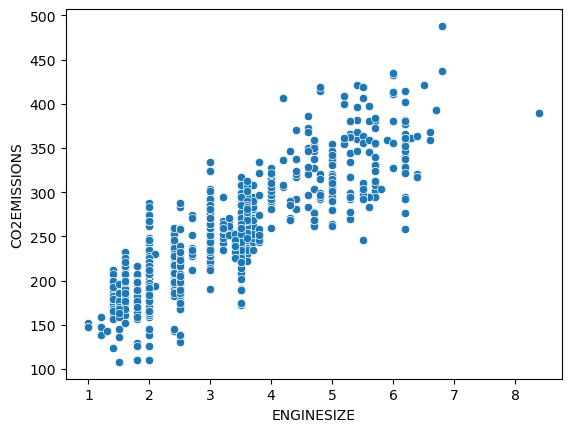

In [21]:
sns.scatterplot(df, x='ENGINESIZE', y='CO2EMISSIONS');

<p>The scatter plot bellow shows a clear linear relationship between Enginesize and CO2 emissions. In fact, the bigger is the engine, the more CO2 it emmits.</p>

<p>Let's now visualize the distribution of CO2 emmisions per type of fuel using a boxplot.</p>

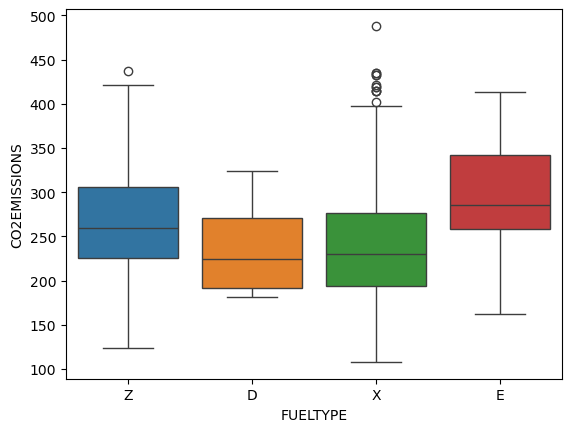

In [82]:
sns.boxplot(df, x='FUELTYPE', y='CO2EMISSIONS', hue='FUELTYPE');

<p>We can see that the fuel named X has a CO2 emmisions distribution larger than any other type of fuel.</p>

In [38]:
print("Here are the unique types of Transmissions that exist in the dataset:")
df['TRANSMISSION'].unique()

Here are the unique types of Transmissions that exist in the dataset:


array(['AS5', 'M6', 'AV7', 'AS6', 'A6', 'AM7', 'AV8', 'AS8', 'A7', 'A8',
       'M7', 'A4', 'M5', 'AV', 'A5', 'AM6', 'AS7', 'A9', 'AS9', 'AV6',
       'AS4', 'AM5'], dtype=object)

<p>Let's now evaluate the relationship between different fuel consumptions given in the dataset and the engine size</p>

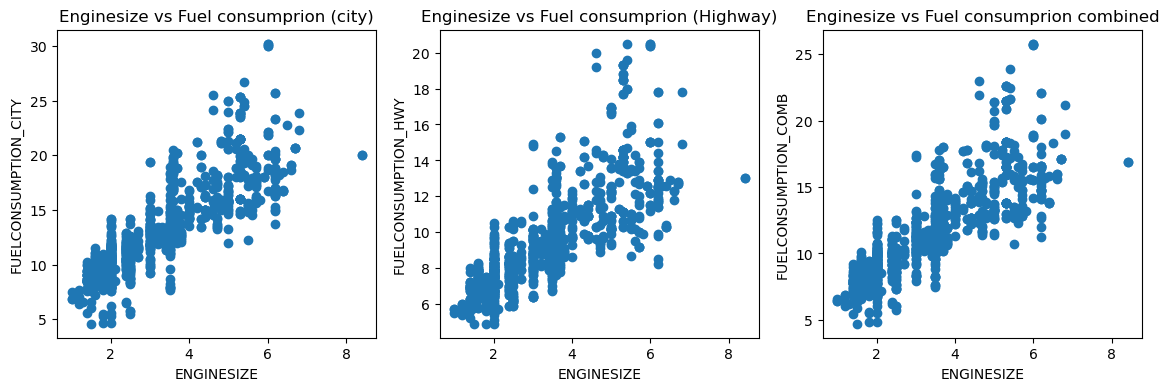

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(14,4));

axes[0].scatter('ENGINESIZE', 'FUELCONSUMPTION_CITY', data=df);
axes[0].set_title('Enginesize vs Fuel consumprion (city)')
axes[0].set_xlabel('ENGINESIZE')
axes[0].set_ylabel('FUELCONSUMPTION_CITY')

axes[1].scatter('ENGINESIZE', 'FUELCONSUMPTION_HWY', data=df);
axes[1].set_title('Enginesize vs Fuel consumprion (Highway)')
axes[1].set_xlabel('ENGINESIZE')
axes[1].set_ylabel('FUELCONSUMPTION_HWY')

axes[2].scatter('ENGINESIZE', 'FUELCONSUMPTION_COMB', data=df);
axes[2].set_title('Enginesize vs Fuel consumprion combined')
axes[2].set_xlabel('ENGINESIZE')
axes[2].set_ylabel('FUELCONSUMPTION_COMB');

<p>With no surprise, the bigger the engine is, the larger its fuel consuption per distance (l/100km), regarless of the type of fuel.</p>

<p>Let's now take a look at relationships between different fuel consuption features and CO2 emmision feature</p>

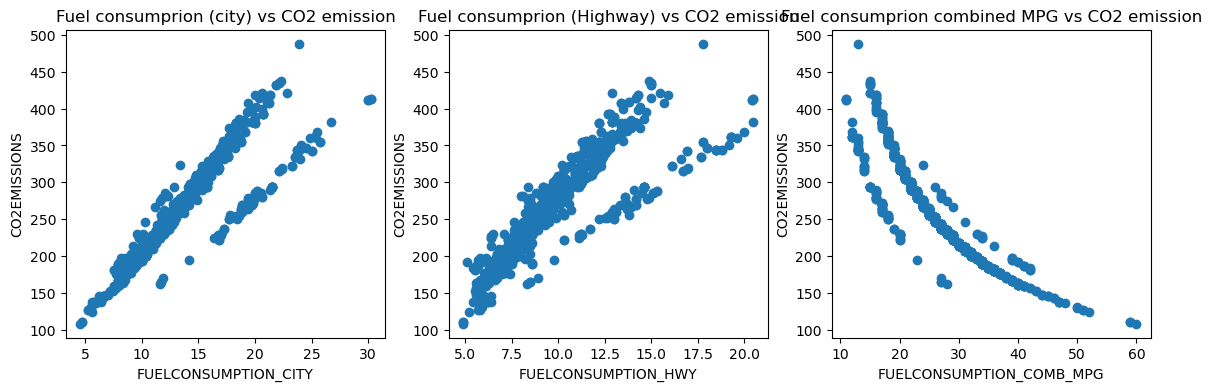

In [192]:
fig, axes = plt.subplots(1, 3, figsize=(14,4));

axes[0].scatter('FUELCONSUMPTION_CITY', 'CO2EMISSIONS', data=df);
axes[0].set_title('Fuel consumprion (city) vs CO2 emission')
axes[0].set_ylabel('CO2EMISSIONS',)
axes[0].set_xlabel('FUELCONSUMPTION_CITY')

axes[1].scatter('FUELCONSUMPTION_HWY', 'CO2EMISSIONS', data=df);
axes[1].set_title('Fuel consumprion (Highway) vs CO2 emission')
axes[1].set_ylabel('CO2EMISSIONS')
axes[1].set_xlabel('FUELCONSUMPTION_HWY')

axes[2].scatter('FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS', data=df);
axes[2].set_title('Fuel consumprion combined MPG vs CO2 emission')
axes[2].set_ylabel('CO2EMISSIONS')
axes[2].set_xlabel('FUELCONSUMPTION_COMB_MPG');

<p>Finally, befor ML models development, let's visualize the correlations between each and all of the numeric features using a heatmap</p>

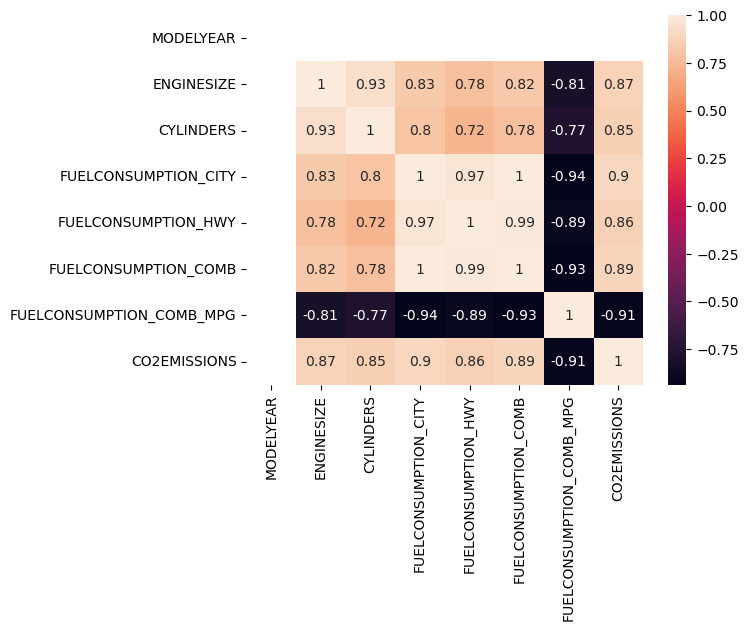

In [41]:
sns.heatmap(df.corr(numeric_only=True), annot=True);

In [50]:
df.columns

Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')

<p style="font-size: 22px; font-weight: bold;">Model development</p>

In [239]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

<p>The model we are going to use is multi-linear regression, Random firest, and Decision tree, and then we will keep the best peforming model. For that, X will be constituted by the features that are correlated to our target feature (the ones analysed on the heatmap below)</p>

In [97]:
X = df[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB', 'FUELCONSUMPTION_COMB_MPG']]

In [99]:
X.head()

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG
0,2.0,4,9.9,6.7,8.5,33
1,2.4,4,11.2,7.7,9.6,29
2,1.5,4,6.0,5.8,5.9,48
3,3.5,6,12.7,9.1,11.1,25
4,3.5,6,12.1,8.7,10.6,27


In [105]:
y = df['CO2EMISSIONS']

In [107]:
# we'll need to scale the data because they have different ranges
scaler = StandardScaler()

In [109]:
model_1 = LinearRegression()

In [113]:
model_2 = RandomForestRegressor()

In [163]:
model_3 = DecisionTreeRegressor(max_depth=6)

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=101)

In [119]:
scaler.fit(X_train)

StandardScaler()

In [121]:
X_train_scaled = scaler.transform(X_train)

<p style="font-size: 22px; font-weight: bold;">Model training without gradient descent</p>

In [123]:
X_test_scaled = scaler.transform(X_test)

In [125]:
model_1.fit(X_train_scaled, y_train)

LinearRegression()

In [127]:
model_2.fit(X_train_scaled, y_train)

RandomForestRegressor()

In [165]:
model_3.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=6)

<p style="font-size: 22px; font-weight: bold;">Model evaluation</p>

In [149]:
def predict_and_evaluate(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    MSE = mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    R2_score = r2_score(y_test, y_pred)
    print('Root mean squared error:', round(RMSE,4))
    print('R2 score:', round(R2_score,4))

In [151]:
# Linear Regression model
predict_and_evaluate(model_1, X_test_scaled, y_test)

Root mean squared error: 19.6702
R2 score: 0.9018


In [153]:
# Random Forest model
predict_and_evaluate(model_2, X_test_scaled, y_test)

Root mean squared error: 11.9543
R2 score: 0.9637


In [167]:
# Decision tree model
predict_and_evaluate(model_3, X_test_scaled, y_test)

Root mean squared error: 14.7078
R2 score: 0.9451


<p style="font-size: 22px; font-weight: bold;">Model training, testing and evaluation using Gradient descent</p>

In [271]:
learning_rates = [0.0001, 0.001, 0.01]
epochs = 50

best_gd_model = None
best_lr = None
best_test_loss = np.inf

for lr in learning_rates:
    gd_model = SGDRegressor(
        loss='squared_error',
        penalty=None,
        learning_rate='constant',
        eta0=lr,
        max_iter=1,
        tol=None,
        random_state=101)

    train_losses = []
    test_losses = []

    for _ in range(epochs):
        gd_model.partial_fit(X_train_scaled, y_train)
        train_losses.append(mean_squared_error(y_train, gd_model.predict(X_train_scaled)))
        test_losses.append(mean_squared_error(y_test, gd_model.predict(X_test_scaled)))

    if test_losses[-1] < best_test_loss:
        best_test_loss = test_losses[-1]
        best_lr = lr
        best_gd_model = gd_model
        best_train_losses = train_losses
        best_test_losses = test_losses

print(f'Best learning rate: {best_lr}')
print(f'Test RMSE: {np.sqrt(best_test_loss):.4f}')

Best learning rate: 0.001
Test RMSE: 19.6810


The reported best learning rate is the step size that gave the most stable and accurate learning for our data, and the RMSE tells us the average prediction error in CO2 units.

In [252]:
results = []
models = {
    'Linear Regression': model_1,
    'Decision Tree': model_3,
    'Random Forest': model_2,
    'Gradient Descent Linear Regression': best_gd_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    })

pd.DataFrame(results).sort_values('RMSE')

,Model,RMSE,R2
2,Random Forest,11.954348,0.963748
1,Decision Tree,14.707764,0.945125
0,Linear Regression,19.670221,0.901848
3,Gradient Descent Linear Regression,19.680957,0.901741


<p>Based on the prediction metrics above, we noticed that the Random Forest model has a smaller RMSE than the two others (11.9543). Additionally, the Random Forest model explain more variance of the dataset than the two other models (0.9637).
<br>Therefore, we will choose the <strong>Random Forest</strong> model for our project.
</p>

<p>Next, let's now verify if the model is ready for real world-data</p>

In [283]:
print(f'CO2 emissions range: [{y.min()} - {y.max()}]')

CO2 emissions range: [108 - 488]


<p>Comperaring the root mean squared error (11.9543) to the CO2 feature range [108 - 488], I judge that the RMSE is acceptable.<br>Therefore, my model is ready for real world unseen data.</p>

In [286]:
# Let's then save the best model
best_model = model_2
model_path = "model/random_forest_least_loss.pkl"
joblib.dump(best_model, model_path)
print(f'Model saved to: "{model_path}"')

Model saved to: "model/random_forest_least_loss.pkl"


<p>Let's now create the code for making prediction on one data point in the test dataset</p>

In [289]:
i = 0  # one row from test data
x_one = X_test.iloc[[i]]
y_true = y_test.iloc[i]

y_pred = model_2.predict(scaler.transform(x_one))[0]

print(f"Actual CO2: {y_true:.2f}")
print(f"Predicted CO2: {y_pred:.2f}")

Actual CO2: 192.00
Predicted CO2: 191.59


Let's now visualize the training loss metric (MSE function)

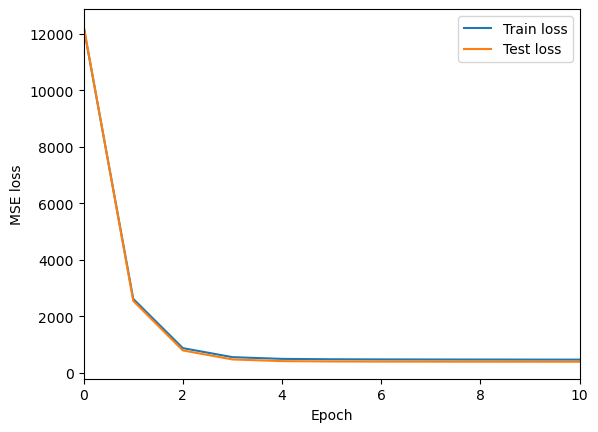

In [256]:
plt.plot(best_train_losses, label='Train loss')
plt.plot(best_test_losses, label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.xlim(0, 10)
plt.legend()
plt.show()

The training loss decreases over epochs, which means the gradient-descent linear model is learning the relationship in the data. If the test loss also decreases and stays close to the training loss, the model is generalizing well; if the gap becomes large, it suggests overfitting.

<p>Now, let's draws a scatter plot of the final linear line that fits the dataset before and after fiting</p>

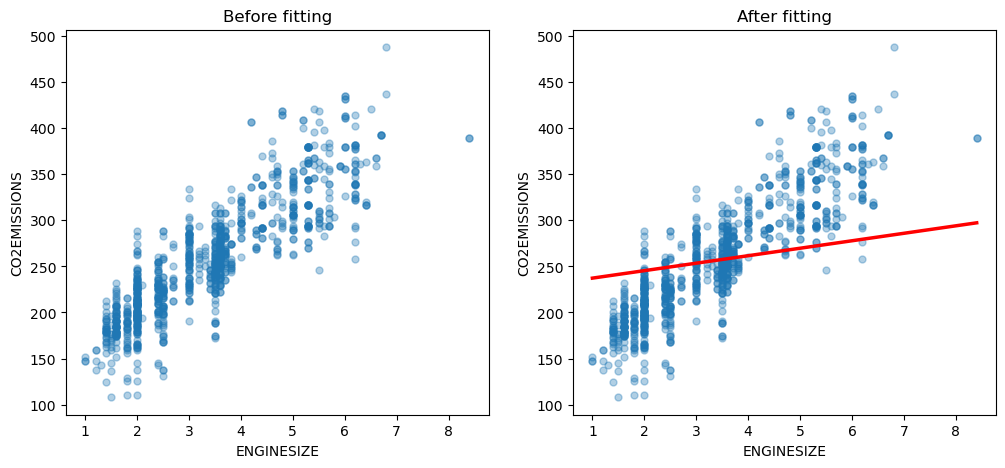

In [258]:
feature = 'ENGINESIZE'
x_line = np.linspace(X[feature].min(), X[feature].max(), 200)
X_line = pd.DataFrame(np.tile(X.mean().values, (len(x_line), 1)), columns=X.columns)
X_line[feature] = x_line
y_line = best_gd_model.predict(scaler.transform(X_line))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X[feature], y, alpha=0.35, s=25)
axes[0].set_title('Before fitting')
axes[0].set_xlabel('ENGINESIZE')
axes[0].set_ylabel('CO2EMISSIONS')

axes[1].scatter(X[feature], y, alpha=0.35, s=25)
axes[1].plot(x_line, y_line, color='red', linewidth=2.5)
axes[1].set_title('After fitting')
axes[1].set_xlabel('ENGINESIZE')
axes[1].set_ylabel('CO2EMISSIONS')

plt.show()

The “before” plot shows only raw points (no model fit), so the trend is visible but not quantified. The “after” plot adds the fitted linear line, which summarizes the average direction of the relationship between engine size and CO2 emissions; points far from the line are prediction errors/noise.